In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import sys
import matplotlib.pyplot as plt
sys.path.insert(1, '../src')

from FDEM1D import FDEM1DModelling_nosort, LCModelling

from showStitched import showStitchedModels

from Plot import grid

In [3]:
print('Using files:')
print('data/data_3DChannel_nosort_topo.npy')
print()

# model parameters [h_1, sigma_1, sigma_2]

data_true = np.load('data/data_3DChannel_nosort_topo.npy')



Using files:
data/data_3DChannel_nosort_topo.npy



In [4]:
# Load true model

model_true_full = np.load('models/model_3DChannel_topo.npy')
np.shape(model_true_full)

(40, 40, 5)

In [5]:
# For each line (40 positions)
npos = 40

# Define a start model
model_ini = np.ones((npos, 3))
model_ini[:,0] = model_ini[:,0]*2   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.1 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.1 # initial sigma_2

In [6]:
model_true = np.zeros((40,40,3))
model_true[:,:,0] = model_true_full[:,:,1]
model_true[:,:,1] = model_true_full[:,:,3]
model_true[:,:,2] = model_true_full[:,:,4]

In [7]:
nLines = len(data_true)/npos
# number of lines nLines

In [8]:
# number of layers
nLayers = np.shape(model_ini)[1] -1

# number of measurement positions 
#npos = len(data_true)

model_inv_all = []
data_inv_all = []

for nL in range(int(nLines)):
    print('Inverting line:', nL)
    data_t = data_true[nL*npos : (nL+1)* npos].copy()
    
    LCI = LCModelling(FDEM1DModelling_nosort)
    
    LCI.initJacobian(dataVals=data_t, nLay=nLayers)
    LCI.createJacobian(model_ini)
    LCI.constraint_matrix(data_t, nLay=nLayers)
    LCI.normalization(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
    LCI.createWeight(data_t, cWeight_1=1, cWeight_2=1, nLay=nLayers)
    LCI.createConstraints()

    # Set transforms
    #transData = pg.trans.TransLog()
    transThk = pg.trans.TransLogLU(1,4)
    transSig = pg.trans.TransLogLU(5/1000,200/1000)
    
    LCI.region(1).setTransModel(transThk)
    LCI.region(2).setTransModel(transSig)
    
    # Create data vector
    data_true_vector = data_t.ravel()
    relativeError = np.ones_like(data_true_vector)*1e-3 

    # Run inversion
    inv = pg.Inversion(LCI)
    #inv.dataTrans = transData
    model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1 )
    
    model_inv_all.append(np.array(model_inv).reshape(np.shape(model_ini)))
    data_inv = np.array(inv.response)
    data_inv_all.append(data_inv.reshape(np.shape(data_t)))

Inverting line: 0
Inversion is normalized
Jacobian size: 702 117 720


14/01/25 - 13:06:36 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/01/25 - 13:06:36 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f9b0ad10c20>
Inverting line: 1
Inversion is normalized
Jacobian size: 702 117 720


14/01/25 - 13:06:45 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/01/25 - 13:06:45 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f9b0ad11b20>
Inverting line: 2
Inversion is normalized
Jacobian size: 702 117 720


...

cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f9b0c9e42c0>
Inverting line: 38
Inversion is normalized
Jacobian size: 702 117 720


14/01/25 - 13:09:00 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/01/25 - 13:09:00 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f9b0ad99b70>
Inverting line: 39
Inversion is normalized
Jacobian size: 702 117 720


14/01/25 - 13:09:03 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
14/01/25 - 13:09:03 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7f9b0ad9bfb0>


In [9]:
m = np.array(model_inv_all)
data_inv_all = np.array(data_inv_all)

In [10]:
m.shape

(40, 40, 3)

In [11]:
model_true.shape

(40, 40, 3)

In [12]:
# Append air layer

m_inv = np.zeros_like(model_true_full)
m_inv[:,:,0] = model_true_full[:,:,0].T
m_inv[:,:,1] = m[:,:,0]
m_inv[:,:,2] = model_true_full[:,:,2]*0
m_inv[:,:,3:] = m[:,:,1:]

In [13]:
m_inv[:,:,2:] = m_inv[:,:,2:]*1000
model_true_full[:,:,2:] = model_true_full[:,:,2:]*1000
model_true_full[:,:,2] = model_true_full[:,:,2]*0

In [14]:
m[:,:,1:] = m[:,:,1:]*1000
model_true[:,:,1:] = model_true[:,:,1:]*1000

In [15]:
model_inv_grid = []

model_true_grid = []

for i in range(m.shape[0]):
    model_inv_grid.append(grid(m_inv[i,:,:], depthmax=6, nlay=3))

for i in range(40):
    model_true_grid.append(grid(model_true_full[:,i,:], depthmax=6, nlay=3))

/tmp/ipykernel_3134330/4279845437.py:10: RuntimeWarning: invalid value encountered in divide
  c2 = ax[2].imshow(np.abs((model_inv_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([0, 39,-6,0]), cmap='bwr', aspect=1.3, vmin=1, vmax=100, norm='log')


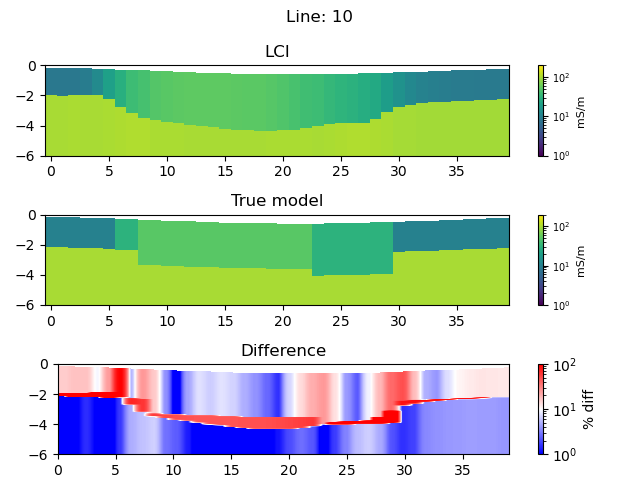

In [48]:
fig, ax = plt.subplots(3, )

l =10

showStitchedModels(m_inv[l,:,:], zMax= 6, cMin=1, cMax=200, ax=ax[0], label='mS/m')
ax[0].set_title('LCI')
showStitchedModels(model_true_full[:,l,:], zMax= 6, cMin=1, cMax=200, ax=ax[1], label='mS/m')
ax[1].set_title('True model')

c2 = ax[2].imshow(np.abs((model_inv_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([0, 39,-6,0]), cmap='bwr', aspect=1.3, vmin=1, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[2], label='% diff')
ax[2].set_title('Difference')

fig.suptitle('Line: '+str( l))

plt.tight_layout()

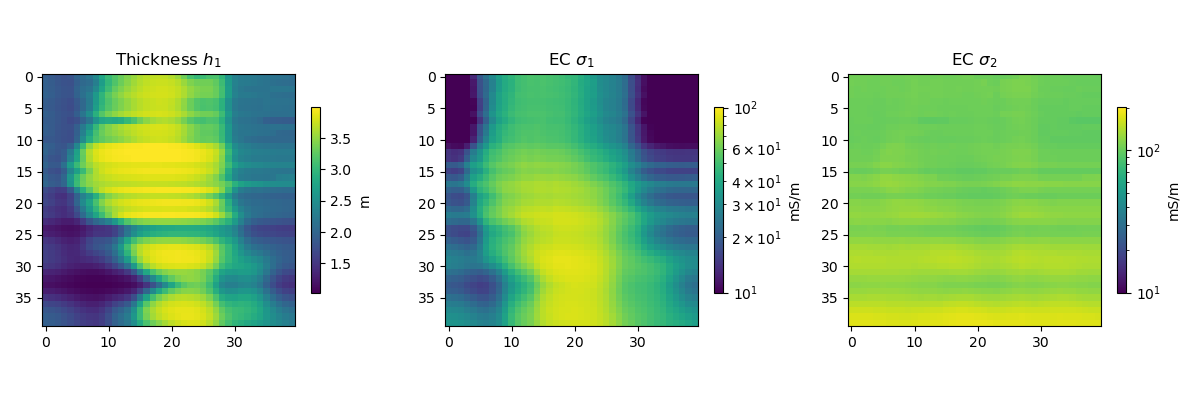

In [35]:


fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(m[:,:,0], vmin=np.min(m[:,:,0]), vmax=np.max(m[:,:,0]))
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(m[:,:,1], vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(m[:,:,2], vmin =10, vmax=200, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

/tmp/ipykernel_3134330/505616766.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,3, figsize=(12,4))


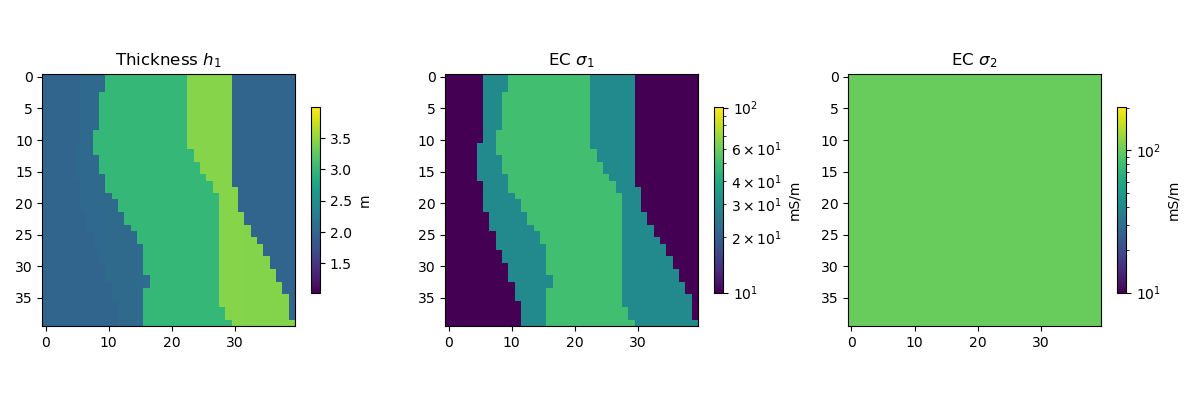

In [36]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T, vmin=np.min(m[:,:,0]), vmax=np.max(m[:,:,0]),)
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T, vmin =10, vmax=200, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

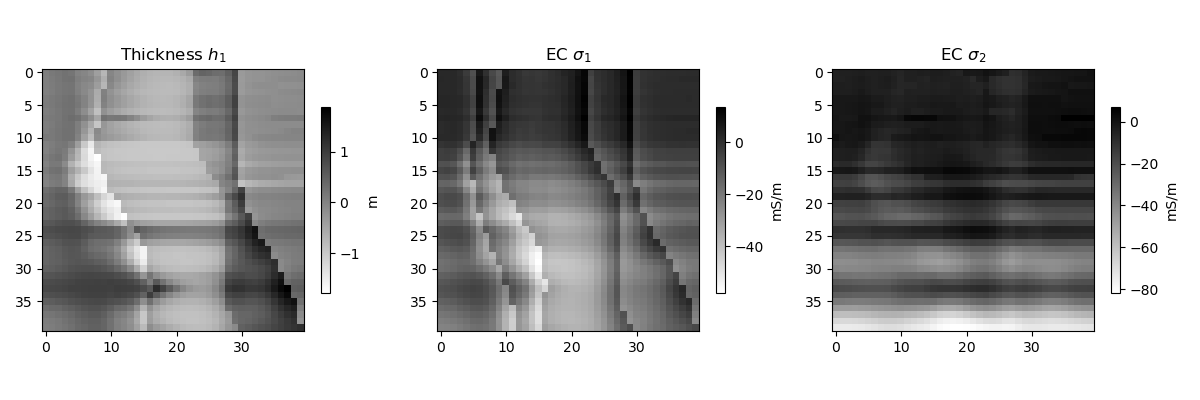

In [19]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T-m[:,:,0], cmap='binary')
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T-m[:,:,1], cmap='binary')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T-m[:,:,2], cmap='binary')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

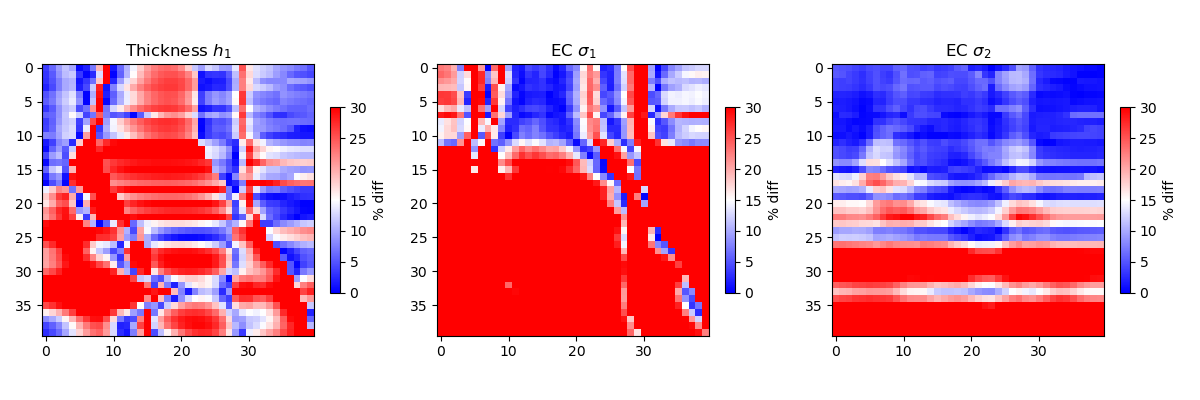

In [20]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(np.abs((model_true[:,:,0].T-m[:,:,0])/model_true[:,:,0].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c1, ax=ax[0], label='% diff', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(np.abs((model_true[:,:,1].T-m[:,:,1])/model_true[:,:,1].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c2, ax=ax[1], label='% diff', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(np.abs((model_true[:,:,2].T-m[:,:,2])/model_true[:,:,2].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c3, ax=ax[2], label='% diff', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

# Check data fit

In [20]:
# Data in PPT

d_true = (data_true.copy())*1000
d_inv = (data_inv_all)*1000

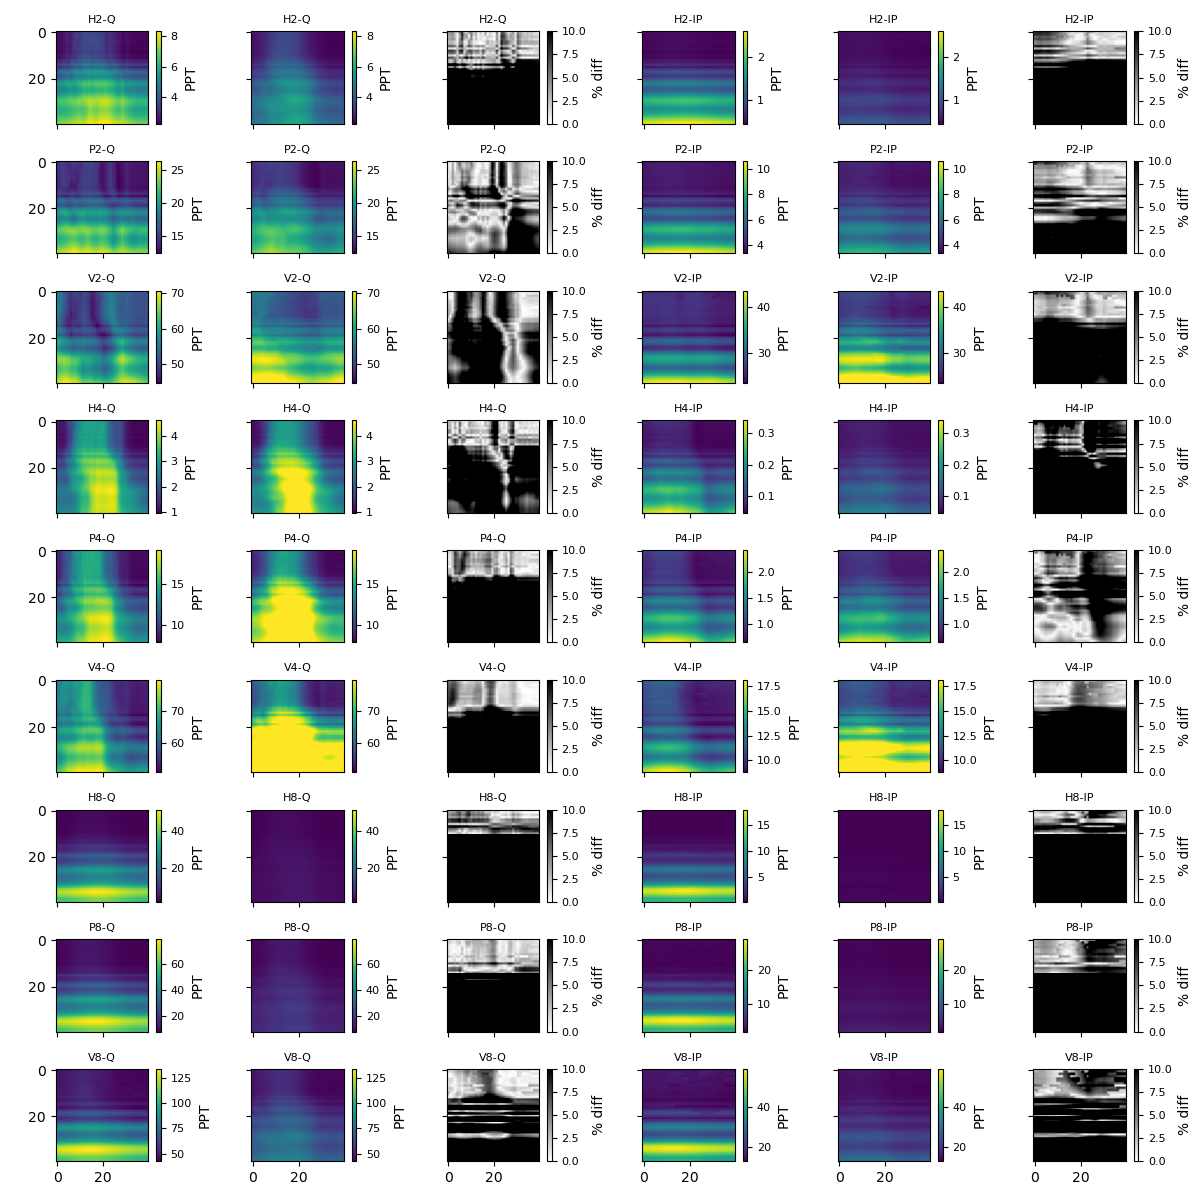

In [21]:
fig, ax = plt.subplots(9,6, figsize=(12,12), sharey=True, sharex=True)

configs = ['H2-Q', 'P2-Q', 'V2-Q', 'H4-Q', 'P4-Q', 'V4-Q', 'H8-Q', 'P8-Q', 'V8-Q', 
           'H2-IP', 'P2-IP', 'V2-IP', 'H4-IP', 'P4-IP', 'V4-IP', 'H8-IP', 'P8-IP', 'V8-IP', ]

fs=8

for i in range(9):
    vmin = min(d_true[:,i])
    vmax = max(d_true[:,i])
    
    c=ax[i,0].imshow(d_true[:,i].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,0].set_title(configs[i], fontsize=fs)
    cb = fig.colorbar(c, ax=ax[i,0], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,1].imshow(d_inv[:,:,i], vmin=vmin, vmax=vmax)
    ax[i,1].set_title(configs[i], fontsize=fs)
    cb =fig.colorbar(c, ax=ax[i,1], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,2].imshow(np.abs((d_true[:,i].reshape(40,40) - d_inv[:,:,i])/d_true[:,i].reshape(40,40))*100, cmap='binary', vmin=0, vmax=10)
    ax[i,2].set_title(configs[i], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,2], label='% diff')
    cb.ax.tick_params(labelsize=fs)

    vmin = min(d_true[:,i+9])
    vmax = max(d_true[:,i+9])
    
    c=ax[i,3].imshow(d_true[:,i+9].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,3].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,3], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,4].imshow(d_inv[:,:,i+9], vmin=vmin, vmax=vmax)
    ax[i,4].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,4], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,5].imshow(np.abs((d_true[:,i+9].reshape(40,40) - d_inv[:,:,i+9])/d_true[:,i+9].reshape(40,40))*100, cmap='binary', vmin=0, vmax=10)
    ax[i,5].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,5], label='% diff')
    cb.ax.tick_params(labelsize=fs)


plt.tight_layout()

In [44]:
np.save('models/model_LCI_Channel_topo', m_inv)

In [45]:
np.save('models/model_LCI_Channel_grid_topo', model_inv_grid)

In [46]:
np.save('models/model_true_grid_topo', model_true_grid)